In [1]:
# =============================================================================
# STEP 0: Force reload modules (run this first after code changes!)
# =============================================================================
import importlib
import src.data_loader
import src.features
import src.models.base
import src.models.goals
import src.models.assists
import src.models.minutes
import src.models.defcon
import src.models.clean_sheet
import src.models.bonus
import src.models.cards
import src.models.saves
import src.pipeline
import src.viz

importlib.reload(src.data_loader)
importlib.reload(src.features)
importlib.reload(src.models.base)
importlib.reload(src.models.goals)
importlib.reload(src.models.assists)
importlib.reload(src.models.minutes)
importlib.reload(src.models.defcon)
importlib.reload(src.models.clean_sheet)
importlib.reload(src.models.bonus)
importlib.reload(src.models.cards)
importlib.reload(src.models.saves)
importlib.reload(src.pipeline)
importlib.reload(src.viz)

print("All modules reloaded.")

All modules reloaded.


In [2]:
# =============================================================================
# STEP 1: Update Data (optional - only if you need fresh gameweek data)
# =============================================================================
!python scrape_update_data.py --gameweek 29
# !python scrape_update_data.py --auto

FotMob Incremental Data Updater

Season: 2025/2026
Fetching fixture list...
Found 291 completed matches in 2025/2026
Checking existing data in: player_stats.csv
Found 2948 existing match IDs in data
Resolving FPL gameweeks [29] via FPL API...
  FPL API returned 10 fixtures for GW [29]
  Matched 10 FotMob fixtures
  Skipping 10 matches already in data
  0 new matches to scrape
No matches to scrape!


In [ ]:
# =============================================================================
# STEP 2: Run the Pipeline
# =============================================================================
from src.pipeline import FPLPipeline
from src.experiment_log import clear_experiments

pipeline = FPLPipeline('data', n_sims=5000)
pipeline.load_data()
pipeline.compute_features()

# Clear old experiments (old MAE was not using 25/26 actuals with bonus)
clear_experiments('data')
print("Cleared old experiment history (incompatible MAE calculation)")

# Full hyperparameter tuning (all models, 2025/26 holdout)
pipeline.tune(
    n_iter=100,
    use_subprocess=True,
    test_season='2025/2026',
    description='baseline: full tune, 5k sims, 25/26 holdout inc-bonus MAE',
)

# Train final models on all data
pipeline.train()

# Predict
predictions = pipeline.predict(gameweek=30, season='2025/2026')

In [4]:
# =============================================================================
# STEP 3: View Top Players
# =============================================================================
# Top 20 by expected points with full prediction breakdown
display_cols = [
    'player_name', 'team', 'fpl_position', 'opponent', 'is_home',
    'pred_minutes', 'pred_exp_goals', 'pred_exp_assists', 
    'pred_cs_prob', 'pred_2plus_conceded', 'pred_4plus_conceded',
    'pred_defcon_prob', 'pred_exp_saves',
    'pred_yellow_prob', 'pred_red_prob',
    'pred_bonus', 'exp_total_pts'
]
available_cols = [c for c in display_cols if c in predictions.columns]
predictions.loc[predictions['fpl_position']!="GK"].nlargest(20, 'exp_total_pts')[available_cols].round(2)

,player_name,team,fpl_position,opponent,is_home,pred_minutes,pred_exp_goals,pred_exp_assists,pred_cs_prob,pred_2plus_conceded,pred_4plus_conceded,pred_defcon_prob,pred_exp_saves,pred_yellow_prob,pred_red_prob,pred_bonus,exp_total_pts
233,Jurriën Timber,Arsenal,DEF,Everton,1,88.629997,0.15,0.07,0.52,0.17,0.01,0.17,0.0,0.16,0.00,0.29,5.45
54,Bruno Fernandes,Manchester United,MID,Aston Villa,1,88.660004,0.35,0.23,0.30,0.34,0.03,0.12,0.0,0.14,0.00,0.57,5.38
165,Gabriel,Arsenal,DEF,Everton,1,88.860001,0.09,0.05,0.52,0.17,0.01,0.23,0.0,0.11,0.00,0.36,5.26
223,Bryan Mbeumo,Manchester United,MID,Aston Villa,1,88.000000,0.38,0.19,0.30,0.34,0.03,0.01,0.0,0.10,0.00,0.49,5.17
293,Cole Palmer,Chelsea,MID,Newcastle,1,81.949997,0.40,0.14,0.36,0.31,0.03,0.01,0.0,0.09,0.00,0.44,5.14
193,Daniel Muñoz,Crystal Palace,DEF,Leeds,1,88.000000,0.14,0.09,0.30,0.33,0.03,0.49,0.0,0.18,0.01,0.33,5.08
20,Casemiro,Manchester United,MID,Aston Villa,1,85.879997,0.19,0.15,0.30,0.34,0.03,0.58,0.0,0.18,0.01,0.37,5.07
40,Mohamed Salah,Liverpool,MID,Spurs,1,88.000000,0.33,0.19,0.36,0.24,0.02,0.00,0.0,0.07,0.00,0.48,4.99
401,Max Alleyne,Manchester City,DEF,West Ham,0,88.230003,0.11,0.07,0.36,0.32,0.03,0.27,0.0,0.10,0.00,0.33,4.72
21,Virgil van Dijk,Liverpool,DEF,Spurs,1,89.029999,0.11,0.05,0.36,0.24,0.02,0.27,0.0,0.05,0.00,0.25,4.69


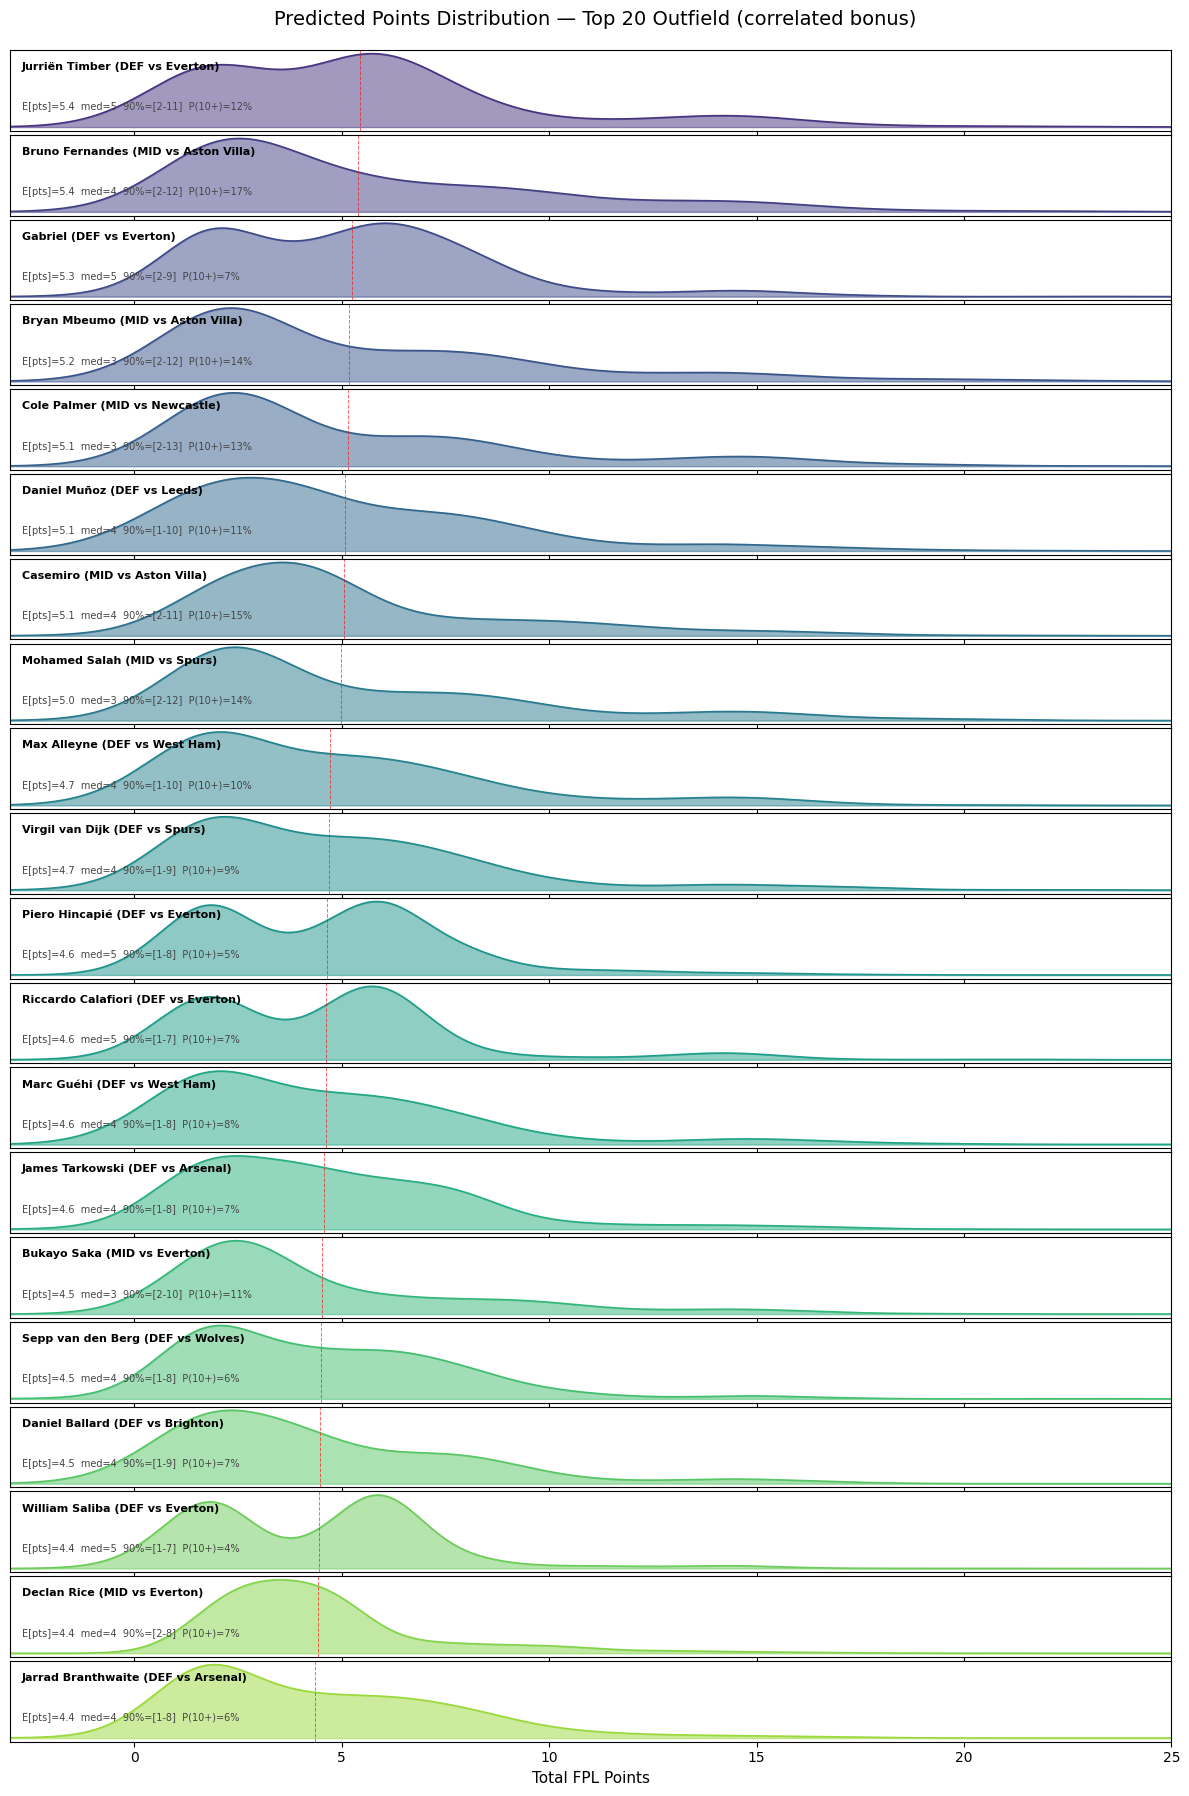

In [5]:
# =============================================================================
# Points Distribution (Monte Carlo) - Top 20 outfield players
# Uses correlated samples from BonusModel (goals/assists/CS drive bonus)
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

FPL_GOAL_PTS = {'GK': 6, 'DEF': 6, 'MID': 5, 'FWD': 4}
np.random.seed(42)

top20 = predictions[predictions['fpl_position'] != 'GK'].nlargest(20, 'exp_total_pts')

# Get correlated simulation arrays from the bonus model
sims = pipeline.last_simulations
sim_names = sims['player_names']  # ordered list matching simulation columns
sim_goals = sims['goals']         # (n_sims, n_players)
sim_assists = sims['assists']
sim_cs = sims['cs']
sim_bonus = sims['bonus']
N_SIMS = sim_goals.shape[0]

# Build name->index lookup for the simulation arrays
name_to_idx = {}
for idx, name in enumerate(sim_names):
    name_to_idx.setdefault(name, idx)  # first occurrence (pre-DGW aggregation)

# Simulate all players
sim_results = []
for _, row in top20.iterrows():
    pos = row['fpl_position']
    mins = row.get('pred_minutes', 0)
    player_name = row['player_name']

    # Look up this player's index in the BonusModel simulation arrays
    pidx = name_to_idx.get(player_name)

    if pidx is not None:
        # Use correlated samples from BonusModel
        goals = sim_goals[:, pidx]
        assists = sim_assists[:, pidx]
        cs = sim_cs[:, pidx]
        bonus_pts = sim_bonus[:, pidx]
    else:
        # Fallback: independent sampling (shouldn't normally happen)
        goals = np.random.poisson(max(row.get('pred_exp_goals', 0), 0), N_SIMS)
        assists = np.random.poisson(max(row.get('pred_exp_assists', 0), 0), N_SIMS)
        cs = np.random.binomial(1, min(max(row.get('pred_cs_prob', 0), 0), 1), N_SIMS)
        bonus_pts = np.clip(np.random.poisson(max(row.get('pred_bonus', 0), 0), N_SIMS), 0, 3)

    # Appearance points (deterministic based on predicted minutes)
    app = np.full(N_SIMS, 2 if mins >= 60 else (1 if mins >= 1 else 0))

    # Goal and assist points (from correlated samples)
    goal_pts = goals * FPL_GOAL_PTS.get(pos, 5)
    assist_pts = assists * 3

    # Clean sheet points (from correlated CS samples)
    cs_pts = np.zeros(N_SIMS)
    if mins >= 60 and pos in ['DEF', 'MID']:
        cs_pts = cs * {'DEF': 4, 'MID': 1}.get(pos, 0)

    # Conceded penalty (independently sampled — not in BonusModel)
    conceded_pen = np.zeros(N_SIMS)
    if mins >= 60 and pos == 'DEF':
        conceded_pen = -(np.random.poisson(max(row.get('pred_goals_against', 1.2), 0.01), N_SIMS) // 2)

    # Defcon (independently sampled)
    defcon_pts = np.zeros(N_SIMS)
    if mins >= 60 and pos in ['DEF', 'MID']:
        defcon_pts = np.random.binomial(1, min(max(row.get('pred_defcon_prob', 0), 0), 1), N_SIMS) * 2

    # Cards (independently sampled)
    yellow_pts = -np.random.binomial(1, min(max(row.get('pred_yellow_prob', 0), 0), 1), N_SIMS)
    red_pts = -3 * np.random.binomial(1, min(max(row.get('pred_red_prob', 0), 0), 1), N_SIMS)

    total = app + goal_pts + assist_pts + cs_pts + conceded_pen + defcon_pts + bonus_pts + yellow_pts + red_pts
    sim_results.append((row, total))

# Shared x-axis range
all_totals = np.concatenate([t for _, t in sim_results])
x_min, x_max = all_totals.min() - 1, min(all_totals.max() + 1, 25)
x_grid = np.linspace(x_min, x_max, 300)

# Create figure: one row per player
fig, axes = plt.subplots(20, 1, figsize=(12, 18), sharex=True)
fig.suptitle('Predicted Points Distribution — Top 20 Outfield (correlated bonus)', fontsize=14, y=0.995)

colors = plt.cm.viridis(np.linspace(0.15, 0.85, 20))

for i, (row, total) in enumerate(sim_results):
    ax = axes[i]
    try:
        kde = gaussian_kde(total, bw_method=0.35)
        y = kde(x_grid)
        ax.fill_between(x_grid, y, alpha=0.5, color=colors[i])
        ax.plot(x_grid, y, color=colors[i], linewidth=1.2)
    except Exception:
        ax.hist(total, bins=30, density=True, alpha=0.5, color=colors[i])

    # Stats
    median = np.median(total)
    p10, p90 = np.percentile(total, [10, 90])
    p_10plus = (total >= 10).mean() * 100

    name = row['player_name']
    pos = row['fpl_position']
    opp = row.get('opponent', '?')
    exp_pts = row['exp_total_pts']
    label = f"{name} ({pos} vs {opp})"
    stats_text = f"E[pts]={exp_pts:.1f}  med={median:.0f}  90%=[{p10:.0f}-{p90:.0f}]  P(10+)={p_10plus:.0f}%"

    ax.text(0.01, 0.85, label, transform=ax.transAxes, fontsize=8, fontweight='bold', va='top')
    ax.text(0.01, 0.35, stats_text, transform=ax.transAxes, fontsize=7, va='top', color='#444444')
    ax.axvline(exp_pts, color='red', linewidth=0.7, linestyle='--', alpha=0.6)

    ax.set_yticks([])
    ax.set_xlim(x_min, x_max)
    if i < 19:
        ax.tick_params(axis='x', labelbottom=False)

axes[-1].set_xlabel('Total FPL Points', fontsize=11)
plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.show()

In [ ]:
# =============================================================================
# Interactive Distribution (D3.js) — opens in browser
# =============================================================================
from src.viz import generate_distribution_html, generate_mobile_html
import webbrowser, os

# Get eval metrics from training
viz_metrics = pipeline.get_viz_metrics()

# Desktop version (ridge plot)
html_path = generate_distribution_html(
    predictions,
    pipeline.last_simulations,
    output_path='distributions.html',
    top_n=100,
    gameweek=30,
    metrics=viz_metrics,
)

# Mobile version (card layout)
mobile_path = generate_mobile_html(
    predictions,
    pipeline.last_simulations,
    output_path='distributions_mobile.html',
    top_n=100,
    gameweek=30,
    metrics=viz_metrics,
)

# Save full run (predictions, simulations, params, metrics)
run_dir = pipeline.save_run(
    predictions,
    gameweek=30,
    season='2025/2026',
    description='baseline: full tune, 5k sims, 25/26 holdout inc-bonus MAE',
)

webbrowser.open('file://' + os.path.realpath(html_path))

In [7]:
# =============================================================================
# Top 10 by Position
# =============================================================================
import pandas as pd

# --- FWD & MID: ranked by expected goals + assists ---
for pos in ['FWD', 'MID']:
    df_pos = predictions[predictions['fpl_position'] == pos].copy()
    df_pos['g+a'] = df_pos['pred_exp_goals'] + df_pos['pred_exp_assists']
    cols = ['player_name', 'team', 'opponent', 'is_home',
            'pred_minutes', 'pred_exp_goals', 'pred_exp_assists', 'g+a',
            'pred_yellow_prob', 'exp_total_pts']
    available = [c for c in cols if c in df_pos.columns]
    print(f"\n{'='*70}")
    print(f"  TOP 10 {pos} (ranked by expected G+A)")
    print(f"{'='*70}")
    display(df_pos.nlargest(10, 'g+a')[available].round(2))

# --- DEF: ranked by expected total pts, showing CS/DC/2+ conceded/4+ conceded + G+A ---
df_def = predictions[predictions['fpl_position'] == 'DEF'].copy()
df_def['g+a'] = df_def['pred_exp_goals'] + df_def['pred_exp_assists']
cols_def = ['player_name', 'team', 'opponent', 'is_home',
            'pred_minutes', 'pred_exp_goals', 'pred_exp_assists', 'g+a',
            'pred_cs_prob', 'pred_2plus_conceded', 'pred_4plus_conceded',
            'pred_defcon_prob', 'pred_yellow_prob', 'exp_total_pts']
available_def = [c for c in cols_def if c in df_def.columns]
print(f"\n{'='*70}")
print(f"  TOP 10 DEF (ranked by exp total pts)")
print(f"{'='*70}")
display(df_def.nlargest(10, 'exp_total_pts')[available_def].round(2))

# --- GK: show saves predictions ---
df_gk = predictions[predictions['fpl_position'] == 'GK'].copy()
cols_gk = ['player_name', 'team', 'opponent', 'is_home',
           'pred_minutes', 'pred_exp_saves',
           'pred_cs_prob', 'pred_2plus_conceded', 'pred_4plus_conceded',
           'pred_goals_against', 'pred_yellow_prob',
           'exp_saves_pts', 'exp_total_pts']
available_gk = [c for c in cols_gk if c in df_gk.columns]
print(f"\n{'='*70}")
print(f"  TOP 10 GK (ranked by exp total pts)")
print(f"{'='*70}")
display(df_gk.nlargest(10, 'exp_total_pts')[available_gk].round(2))

# --- FULL POINTS BREAKDOWN: Top 20 players ---
print(f"\n{'='*70}")
print(f"  FULL POINTS BREAKDOWN - TOP 20")
print(f"{'='*70}")
pts_cols = ['player_name', 'team', 'fpl_position', 'opponent',
            'exp_appearance_pts', 'exp_goals_pts', 'exp_assists_pts',
            'exp_cs_pts', 'exp_conceded_penalty', 'exp_saves_pts',
            'exp_defcon_pts', 'exp_bonus_pts', 'exp_yellow_pts', 'exp_red_pts',
            'exp_total_pts']
available_pts = [c for c in pts_cols if c in predictions.columns]
display(predictions.nlargest(20, 'exp_total_pts')[available_pts].round(2))


  TOP 10 FWD (ranked by expected G+A)


,player_name,team,opponent,is_home,pred_minutes,pred_exp_goals,pred_exp_assists,g+a,pred_yellow_prob,exp_total_pts
128,Erling Haaland,Manchester City,West Ham,0,86.110001,0.35,0.11,0.46,0.11,4.29
374,Igor Thiago,Brentford,Wolves,1,88.000000,0.37,0.07,0.44,0.20,4.34
39,Raul Jiménez,Fulham,Nott'm Forest,0,79.910004,0.34,0.08,0.42,0.19,4.14
68,Jarrod Bowen,West Ham United,Man City,1,88.220001,0.29,0.14,0.42,0.09,4.09
74,Ollie Watkins,Aston Villa,Man Utd,0,83.209999,0.31,0.09,0.40,0.19,3.92
115,Jean-Philippe Mateta,Crystal Palace,Leeds,1,88.000000,0.30,0.07,0.37,0.12,3.97
294,Evanilson,Bournemouth,Burnley,0,76.419998,0.29,0.07,0.36,0.11,3.84
279,Benjamin Sesko,Manchester United,Aston Villa,1,63.029999,0.32,0.04,0.36,0.09,3.93
4,Danny Welbeck,Brighton and Hove Albion,Sunderland,0,72.580002,0.27,0.07,0.34,0.11,3.78
262,João Pedro,Chelsea,Newcastle,1,83.599998,0.25,0.08,0.33,0.16,3.53



  TOP 10 MID (ranked by expected G+A)


,player_name,team,opponent,is_home,pred_minutes,pred_exp_goals,pred_exp_assists,g+a,pred_yellow_prob,exp_total_pts
54,Bruno Fernandes,Manchester United,Aston Villa,1,88.660004,0.35,0.23,0.58,0.14,5.38
223,Bryan Mbeumo,Manchester United,Aston Villa,1,88.000000,0.38,0.19,0.57,0.10,5.17
293,Cole Palmer,Chelsea,Newcastle,1,81.949997,0.40,0.14,0.54,0.09,5.14
40,Mohamed Salah,Liverpool,Spurs,1,88.000000,0.33,0.19,0.52,0.07,4.99
249,Bukayo Saka,Arsenal,Everton,1,82.370003,0.25,0.17,0.42,0.16,4.52
159,Marcus Tavernier,Bournemouth,Burnley,0,83.139999,0.24,0.17,0.41,0.14,4.23
224,Antoine Semenyo,Manchester City,West Ham,0,88.000000,0.30,0.11,0.41,0.26,4.31
320,Florian Wirtz,Liverpool,Spurs,1,86.250000,0.23,0.15,0.38,0.13,4.12
169,Cody Gakpo,Liverpool,Spurs,1,82.720001,0.24,0.13,0.36,0.17,4.09
62,Harry Wilson,Fulham,Nott'm Forest,0,84.250000,0.23,0.12,0.35,0.10,3.90



  TOP 10 DEF (ranked by exp total pts)


,player_name,team,opponent,is_home,pred_minutes,pred_exp_goals,pred_exp_assists,g+a,pred_cs_prob,pred_2plus_conceded,pred_4plus_conceded,pred_defcon_prob,pred_yellow_prob,exp_total_pts
233,Jurriën Timber,Arsenal,Everton,1,88.629997,0.15,0.07,0.22,0.52,0.17,0.01,0.17,0.16,5.45
165,Gabriel,Arsenal,Everton,1,88.860001,0.09,0.05,0.13,0.52,0.17,0.01,0.23,0.11,5.26
193,Daniel Muñoz,Crystal Palace,Leeds,1,88.000000,0.14,0.09,0.23,0.30,0.33,0.03,0.49,0.18,5.08
401,Max Alleyne,Manchester City,West Ham,0,88.230003,0.11,0.07,0.18,0.36,0.32,0.03,0.27,0.10,4.72
21,Virgil van Dijk,Liverpool,Spurs,1,89.029999,0.11,0.05,0.15,0.36,0.24,0.02,0.27,0.05,4.69
317,Piero Hincapié,Arsenal,Everton,1,84.730003,0.03,0.08,0.10,0.52,0.17,0.01,0.16,0.13,4.65
297,Riccardo Calafiori,Arsenal,Everton,1,71.940002,0.08,0.04,0.12,0.52,0.17,0.01,0.04,0.11,4.62
184,Marc Guéhi,Manchester City,West Ham,0,89.589996,0.13,0.04,0.18,0.36,0.32,0.03,0.26,0.12,4.61
28,James Tarkowski,Everton,Arsenal,0,88.879997,0.06,0.06,0.12,0.36,0.27,0.02,0.42,0.11,4.58
221,Sepp van den Berg,Brentford,Wolves,1,88.889999,0.06,0.04,0.11,0.36,0.24,0.02,0.32,0.08,4.49



  TOP 10 GK (ranked by exp total pts)


,player_name,team,opponent,is_home,pred_minutes,pred_exp_saves,pred_cs_prob,pred_2plus_conceded,pred_4plus_conceded,pred_goals_against,pred_yellow_prob,exp_saves_pts,exp_total_pts
78,David Raya,Arsenal,Everton,1,89.610001,2.25,0.52,0.17,0.01,0.75,0.00,0.75,5.02
43,Jordan Pickford,Everton,Arsenal,0,89.610001,3.24,0.36,0.27,0.02,1.01,0.00,1.08,4.57
234,Giorgi Mamardashvili,Liverpool,Spurs,1,89.510002,2.69,0.36,0.24,0.02,0.94,0.01,0.90,4.48
333,James Trafford,Manchester City,West Ham,0,89.620003,3.10,0.36,0.32,0.03,1.15,0.02,1.03,4.45
91,Gianluigi Donnarumma,Manchester City,West Ham,0,89.610001,2.99,0.36,0.32,0.03,1.15,0.00,1.00,4.42
158,Robert Sánchez,Chelsea,Newcastle,1,89.580002,2.81,0.36,0.31,0.03,1.13,0.00,0.94,4.40
344,Filip Jörgensen,Chelsea,Newcastle,1,89.180000,2.88,0.36,0.31,0.03,1.13,0.00,0.96,4.38
46,Alisson Becker,Liverpool,Spurs,1,89.610001,2.23,0.36,0.24,0.02,0.94,0.00,0.74,4.33
151,Caoimhín Kelleher,Brentford,Wolves,1,90.000000,2.44,0.36,0.24,0.02,0.93,0.09,0.81,4.27
9,Karl Darlow,Leeds United,Crystal Palace,0,89.529999,3.18,0.30,0.33,0.03,1.17,0.00,1.06,4.26



  FULL POINTS BREAKDOWN - TOP 20


,player_name,team,fpl_position,opponent,exp_appearance_pts,exp_goals_pts,exp_assists_pts,exp_cs_pts,exp_conceded_penalty,exp_saves_pts,exp_defcon_pts,exp_bonus_pts,exp_yellow_pts,exp_red_pts,exp_total_pts
233,Jurriën Timber,Arsenal,DEF,Everton,2.0,0.90,0.21,2.06,-0.18,0.00,0.34,0.29,-0.16,-0.01,5.45
54,Bruno Fernandes,Manchester United,MID,Aston Villa,2.0,1.74,0.69,0.30,0.00,0.00,0.24,0.57,-0.14,-0.01,5.38
165,Gabriel,Arsenal,DEF,Everton,2.0,0.52,0.14,2.06,-0.18,0.00,0.47,0.36,-0.11,-0.01,5.26
223,Bryan Mbeumo,Manchester United,MID,Aston Villa,2.0,1.91,0.56,0.30,0.00,0.00,0.02,0.49,-0.10,-0.01,5.17
293,Cole Palmer,Chelsea,MID,Newcastle,2.0,2.00,0.42,0.36,0.00,0.00,0.03,0.44,-0.09,-0.01,5.14
193,Daniel Muñoz,Crystal Palace,DEF,Leeds,2.0,0.86,0.26,1.21,-0.36,0.00,0.99,0.33,-0.18,-0.02,5.08
20,Casemiro,Manchester United,MID,Aston Villa,2.0,0.96,0.46,0.30,0.00,0.00,1.17,0.37,-0.18,-0.02,5.07
78,David Raya,Arsenal,GK,Everton,2.0,0.18,0.11,2.06,-0.18,0.75,0.00,0.10,-0.00,-0.00,5.02
40,Mohamed Salah,Liverpool,MID,Spurs,2.0,1.67,0.56,0.36,0.00,0.00,0.00,0.48,-0.07,-0.01,4.99
401,Max Alleyne,Manchester City,DEF,West Ham,2.0,0.67,0.21,1.43,-0.35,0.00,0.53,0.33,-0.10,-0.01,4.72


In [ ]:
# =============================================================================
# FPL Points Breakdown: Predicted vs Actual by Category
# Shows where the model over/under-predicts in FPL points terms
# =============================================================================
breakdown = pipeline.points_breakdown()
display(breakdown.style.format({
    'pred_value_avg': '{:.4f}',
    'pred_pts_avg': '{:.4f}',
    'actual_value_avg': '{:.4f}',
    'actual_pts_avg': '{:.4f}',
    'pts_diff': '{:+.4f}',
    'abs_pts_diff': '{:.4f}',
}, na_rep='—').set_caption('FPL Points Breakdown: Predicted vs Actual (test set averages per player-match)'))

In [8]:
predictions[predictions['player_name'].str.contains('Chal', case=False, na=False)][available_cols].round(2)


,player_name,team,fpl_position,opponent,is_home,pred_minutes,pred_exp_goals,pred_exp_assists,pred_cs_prob,pred_2plus_conceded,pred_4plus_conceded,pred_defcon_prob,pred_exp_saves,pred_yellow_prob,pred_red_prob,pred_bonus,exp_total_pts
164,Trevoh Chalobah,Chelsea,DEF,Newcastle,1,88.260002,0.05,0.04,0.36,0.31,0.03,0.35,0.0,0.1,0.0,0.07,4.2


In [9]:
# =============================================================================
# Arsenal xG Analysis: Actual Last 5 Games vs Computed Rolling Features
# =============================================================================

# Get Arsenal's last 5 games from raw match data
arsenal_matches = pipeline.df[
    (pipeline.df['team'].str.contains('Arsenal', case=False, na=False)) &
    (pipeline.df['season'] == '2025/2026')
].copy()

# Get one row per match (team-level aggregation)
arsenal_team = arsenal_matches.groupby(['team', 'opponent', 'season', 'gameweek', 'is_home']).agg({
    'xg': 'sum',  # Team's total xG for the match
    'goals': 'sum',  # Team's goals scored
}).reset_index().sort_values('gameweek', ascending=False)

# Get xGA (opponent's xG against Arsenal) by looking up opponent's xG in that match
# We need to find what the opponent generated against Arsenal
opp_stats = pipeline.df.groupby(['team', 'season', 'gameweek']).agg({
    'xg': 'sum', 
    'goals': 'sum'
}).reset_index()
opp_stats = opp_stats.rename(columns={'team': 'opponent', 'xg': 'xga', 'goals': 'goals_conceded'})

arsenal_team = arsenal_team.merge(opp_stats, on=['opponent', 'season', 'gameweek'], how='left')

print("=" * 70)
print("ARSENAL'S LAST 5 GAMES - ACTUAL xG FOR AND AGAINST")
print("=" * 70)
last5 = arsenal_team.head(5)[['gameweek', 'opponent', 'is_home', 'xg', 'goals', 'xga', 'goals_conceded']]
last5.columns = ['GW', 'Opponent', 'Home', 'xG For', 'Goals', 'xGA (opp xG)', 'Conceded']
print(last5.to_string(index=False))
print(f"\n--- Last 5 Game Averages (what roll5 should approximate) ---")
print(f"  Avg xG For:     {last5['xG For'].mean():.3f}")
print(f"  Avg xGA:        {last5['xGA (opp xG)'].mean():.3f}")
print(f"  Avg Goals:      {last5['Goals'].mean():.2f}")
print(f"  Avg Conceded:   {last5['Conceded'].mean():.2f}")

# Now show the rolling features from predictions
print("\n" + "=" * 70)
print("COMPUTED ROLLING FEATURES (grabbed by model for GW25 prediction)")
print("=" * 70)

# Get an Arsenal player from predictions
arsenal_pred = predictions[predictions['team'].str.contains('Arsenal', case=False, na=False)].iloc[0]
print(f"\nArsenal player sampled: {arsenal_pred['player_name']}")

# Show team xG features (offensive)
print(f"\n--- Team xG Rolling (Arsenal's attacking output) ---")
for window in [1, 3, 5, 10, 30]:
    col = f'team_xg_roll{window}'
    if col in arsenal_pred.index:
        print(f"  {col}: {arsenal_pred[col]:.3f}")

# Show team xGA features (defensive - what opponents generate against Arsenal)
print(f"\n--- Team xGA Rolling (what opponents generate vs Arsenal) ---")
for window in [1, 3, 5, 10, 30]:
    col = f'team_xga_roll{window}'
    if col in arsenal_pred.index:
        print(f"  {col}: {arsenal_pred[col]:.3f}")

# Show goals conceded
print(f"\n--- Team Goals Conceded Rolling ---")
for window in [1, 3, 5, 10, 30]:
    col = f'team_conceded_roll{window}'
    if col in arsenal_pred.index:
        print(f"  {col}: {arsenal_pred[col]:.3f}")

ARSENAL'S LAST 5 GAMES - ACTUAL xG FOR AND AGAINST
  GW                Opponent  Home  xG For  Goals  xGA (opp xG)  Conceded
31.0 Wolverhampton Wanderers     0    1.61    2.0          0.30       2.0
29.0  Brighton & Hove Albion     0    0.46    1.0           NaN       NaN
28.0                 Chelsea     1    1.08    2.0          1.08       0.0
27.0       Tottenham Hotspur     0    2.06    4.0          0.76       1.0
26.0               Brentford     0    0.59    1.0          1.50       1.0

--- Last 5 Game Averages (what roll5 should approximate) ---
  Avg xG For:     1.160
  Avg xGA:        0.910
  Avg Goals:      2.00
  Avg Conceded:   1.00

COMPUTED ROLLING FEATURES (grabbed by model for GW25 prediction)

Arsenal player sampled: Christian Nørgaard

--- Team xG Rolling (Arsenal's attacking output) ---
  team_xg_roll5: 1.136
  team_xg_roll10: 1.288

--- Team xGA Rolling (what opponents generate vs Arsenal) ---
  team_xga_roll1: 0.810
  team_xga_roll3: 0.883
  team_xga_roll5: 0.866
  t

In [10]:
# =============================================================================
# DIAGNOSTIC: Investigate xGA computation bug
# =============================================================================

# Check team name variations in the data
print("Team name variations:")
teams = pipeline.df['team'].unique()
for t in sorted(teams):
    if 'bournemouth' in t.lower() or 'arsenal' in t.lower():
        print(f"  '{t}'")

print("\nOpponent name variations:")
opponents = pipeline.df['opponent'].unique()
for o in sorted(opponents):
    if 'bournemouth' in o.lower() or 'arsenal' in o.lower():
        print(f"  '{o}'")

# Check Arsenal vs Bournemouth game from both perspectives
print("\n" + "=" * 70)
print("Arsenal vs Bournemouth GW20 - BOTH TEAM PERSPECTIVES")
print("=" * 70)

# Arsenal's view (team=Arsenal)
arsenal_view = pipeline.df[
    (pipeline.df['team'].str.contains('Arsenal', case=False)) &
    (pipeline.df['opponent'].str.contains('Bournemouth', case=False)) &
    (pipeline.df['gameweek'] == 20) &
    (pipeline.df['season'] == '2025/2026')
].groupby(['team', 'opponent', 'gameweek']).agg({'xg': 'sum', 'goals': 'sum'}).reset_index()
print("\nArsenal's perspective (team=Arsenal):")
print(arsenal_view)

# Bournemouth's view (team=Bournemouth)  
bournemouth_view = pipeline.df[
    (pipeline.df['team'].str.contains('Bournemouth', case=False)) &
    (pipeline.df['opponent'].str.contains('Arsenal', case=False)) &
    (pipeline.df['gameweek'] == 20) &
    (pipeline.df['season'] == '2025/2026')
].groupby(['team', 'opponent', 'gameweek']).agg({'xg': 'sum', 'goals': 'sum'}).reset_index()
print("\nBournemouth's perspective (team=Bournemouth):")
print(bournemouth_view)

# The xGA for Arsenal SHOULD be Bournemouth's xG (what Bournemouth generated against Arsenal)
if len(bournemouth_view) > 0:
    print(f"\n>>> Arsenal's xGA for GW20 should be: {bournemouth_view['xg'].values[0]:.3f}")
else:
    print("\n>>> ERROR: No Bournemouth perspective found! Team name mismatch?")

Team name variations:
  'Arsenal'
  'Bournemouth'

Opponent name variations:
  'AFC Bournemouth'
  'Arsenal'

Arsenal vs Bournemouth GW20 - BOTH TEAM PERSPECTIVES

Arsenal's perspective (team=Arsenal):
      team         opponent  gameweek    xg  goals
0  Arsenal  AFC Bournemouth      20.0  1.13    3.0

Bournemouth's perspective (team=Bournemouth):
          team opponent  gameweek    xg  goals
0  Bournemouth  Arsenal      20.0  1.43    2.0

>>> Arsenal's xGA for GW20 should be: 1.430


In [11]:
# Quick check: what format do team names actually use?
print("Sample team names:")
print(pipeline.df['team'].value_counts().head(10))
print("\nSample opponent names:")
print(pipeline.df['opponent'].value_counts().head(10))

Sample team names:
team
Brighton and Hove Albion    3229
Liverpool                   3195
Tottenham Hotspur           3189
Wolverhampton Wanderers     3185
Manchester United           3176
Chelsea                     3174
Arsenal                     3174
Newcastle United            3171
Aston Villa                 3170
Crystal Palace              3082
Name: count, dtype: int64

Sample opponent names:
opponent
Manchester City            3208
Wolverhampton Wanderers    3191
Tottenham Hotspur          3171
Brighton & Hove Albion     3168
Aston Villa                3166
Chelsea                    3161
Crystal Palace             3160
Arsenal                    3152
West Ham United            3152
Manchester United          3151
Name: count, dtype: int64
